In [23]:
"""
Conversión de espacio de color RGB a CMY
Autor: Natalia Rendón
Curso: Procesamiento de Imágenes
"""

'\nConversión de espacio de color RGB a CMY\nAutor: Natalia Rendón\nCurso: Procesamiento de Imágenes\n'

In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os


In [18]:
def RGB2CMY(img):
    """
    Convierte una imagen de RGB a CMY (Cian, Magenta, Amarillo)
    
    Parámetros:
    -----------
    img : numpy.ndarray
        Imagen en formato RGB con valores de 0 a 255
        
    Retorna:
    --------
    numpy.ndarray
        Imagen en espacio CMY con valores normalizados (0 a 1)
        
    Ejemplo:
    --------
    >>> imagen_rgb = cv2.imread('foto.jpg')
    >>> imagen_rgb = cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2RGB)
    >>> imagen_cmy = RGB2CMY(imagen_rgb)
    """
    # Validar que la imagen no esté vacía
    if img is None:
        raise ValueError("No se pudo cargar la imagen")
    
    # Validar que tenga 3 canales (RGB)
    if len(img.shape) != 3 or img.shape[2] != 3:
        raise ValueError("La imagen debe tener 3 canales (RGB)")
    
    # Normalizar valores a rango [0,1]
    imagen_rgb_normalized = img.astype(np.float32) / 255.0
    
    # Calcular componentes CMY
    C = 1 - imagen_rgb_normalized[:, :, 0]
    M = 1 - imagen_rgb_normalized[:, :, 1]
    Y = 1 - imagen_rgb_normalized[:, :, 2]
    
    # Combinar canales
    imagen_cmy = cv2.merge((C, M, Y))
    
    return imagen_cmy

def cargar_imagen(ruta_imagen):
    """
    Carga una imagen y la convierte de BGR a RGB
    
    Parámetros:
    -----------
    ruta_imagen : str
        Ruta del archivo de imagen
        
    Retorna:
    --------
    numpy.ndarray
        Imagen en formato RGB
    """
    # Verificar que el archivo existe
    if not os.path.exists(ruta_imagen):
        raise FileNotFoundError(f"No se encontró la imagen: {ruta_imagen}")
    
    # Cargar imagen
    img = cv2.imread(ruta_imagen)
    
    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {ruta_imagen}")
    
    # Convertir BGR a RGB
    imagen_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    return imagen_rgb

def visualizar_comparacion(imagen_rgb, imagen_cmy):
    """
    Muestra dos imágenes lado a lado para comparación
    
    Parámetros:
    -----------
    imagen_rgb : numpy.ndarray
        Imagen en RGB
    imagen_cmy : numpy.ndarray
        Imagen en CMY
    """
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(imagen_rgb)
    plt.title('Imagen RGB')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(imagen_cmy)
    plt.title('Imagen CMY')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

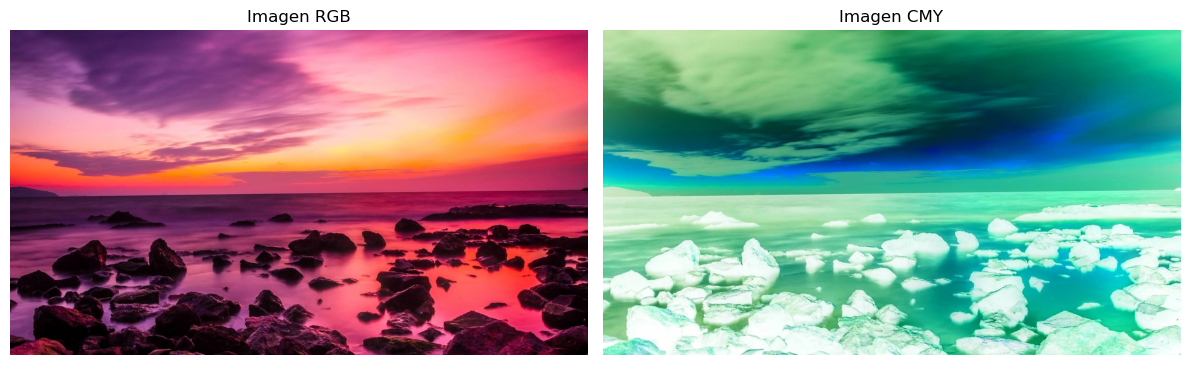

Procesamiento completado exitosamente


In [21]:
# ============ EJECUCIÓN PRINCIPAL ============
if __name__ == "__main__":
    try:
        # Coloca la imagen en la misma carpeta que este script
        ruta_imagen = "sunset.jpg"  # Cambia esto por tu imagen
        
        # Cargar y procesar
        imagen_rgb = cargar_imagen(ruta_imagen)
        imagen_cmy = RGB2CMY(imagen_rgb)
        
        # Visualizar resultados
        visualizar_comparacion(imagen_rgb, imagen_cmy)
        
        print("Procesamiento completado exitosamente")
        
    except Exception as e:
        print(f"Error: {e}")
        print("\nSugerencias:")
        print("- Verifica que la imagen 'sunset.jpg' esté en la misma carpeta")
        print("- Cambia la ruta en la variable 'ruta_imagen'")